In [1]:
%load_ext autoreload
%autoreload 2

In [33]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import numpy as np

from faith.train.data import get_file_paths

In [41]:
files = get_file_paths('bob')

ValueError: File 'bob' does not exist.
Available datasets: ['signals', 'magnetics', 'spectrogram']

In [42]:
files = get_file_paths('magnetics')
print(len(files))

file_name = files[0]
print(file_name)
data = joblib.load(file_name)
for key, value in data.items():
    print(key, value.shape)

1
/scratch/gpfs/EKOLEMEN/hackathon/foundation25/magnetics/170000_0.joblib
mhr (8, 1, 2832874)


KeyError: 'time_ms'

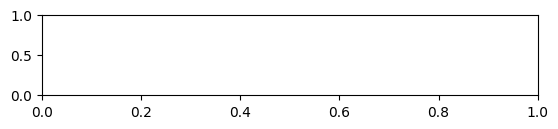

In [28]:
plt.subplot(4, 1, 1)
plt.plot(data['time_ms'][0,0,:])
plt.xlim(0, len(data['time_ms'][0,0,:]))
plt.title('time_ms')
plt.subplot(4, 1, 2)
plt.imshow(np.log(data['mhr'][4] + 1e-6), aspect='auto', origin='lower')
plt.title('mhrb4')
plt.subplot(4, 1, 3)
plt.imshow(np.log(data['co2'][0] + 1e-6), aspect='auto', origin='lower')
plt.title('co2r0')
plt.subplot(4, 1, 4)
plt.imshow(data['pin'][:,0,:], aspect='auto', origin='lower', interpolation='none')
plt.title('pin')
plt.tight_layout()
plt.show()

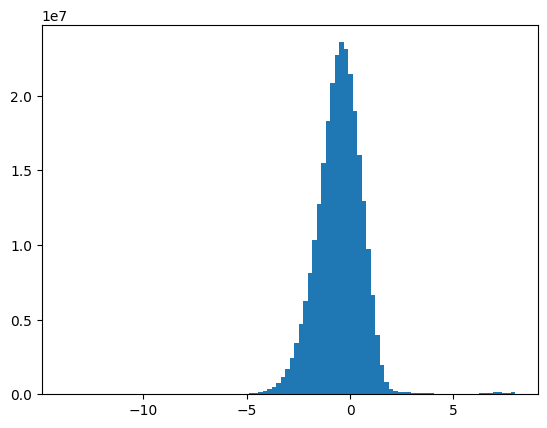

In [5]:
x_flat = np.log(data['ece'] + 1e-6).flatten()
plt.hist(x_flat, bins=100)
plt.show()

In [6]:
num_channels = data['ece'].shape[0]
x_min, x_max = -5, 5
x = np.log1p(data['ece'])
x[x < x_min] = x_min
x[x > x_max] = x_max

In [7]:
from tqdm.auto import tqdm
from concurrent.futures import ThreadPoolExecutor

In [8]:
import matplotlib
# Set the backend BEFORE importing pyplot
matplotlib.use('Agg') 
import matplotlib.pyplot as plt

In [9]:
import os

In [10]:
def create_img(i, data, folder):
    """
    Creates and saves a single image in a thread-safe manner.
    """
    try:
        # Even with the 'Agg' backend, using the explicit object-oriented
        # API is safer and better practice.
        fig, ax = plt.subplots(figsize=(5, 2.5))
        
        ax.imshow(data[i], aspect='auto', origin='lower', cmap='plasma')
        ax.axis('off')
        
        output_path = os.path.join(folder, f'{i}.png')
        fig.savefig(output_path, dpi=150, bbox_inches='tight', pad_inches=0)
        
        # Close the figure to release resources
        plt.close(fig)
        
        return i, None
    except Exception as e:
        return i, str(e)
# Use ThreadPoolExecutor to create images in parallel
with ThreadPoolExecutor(max_workers=48) as executor:
    futures = [executor.submit(create_img, i, x, 'cache2') for i in range(num_channels)]
    for future in tqdm(futures, desc="Creating images"):
        future.result()

/tmp/ipykernel_2987928/3088652785.py:8: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(5, 2.5))


Creating images:   0%|          | 0/48 [00:00<?, ?it/s]

In [16]:
import matplotlib
%matplotlib nbagg
import matplotlib.pyplot as plt

In [19]:
import imageio.v3 as imageio
import os

# Create gif from the saved PNG files
png_files = []
for i in range(num_channels):
    png_file = f'cache2/{i}.png'
    if os.path.exists(png_file):
        png_files.append(png_file)

if png_files:
    # Read images and create gif
    images = []
    for png_file in png_files:
        images.append(imageio.imread(png_file))
    
    # Save as gif
    imageio.imwrite('channels_animation.gif', images, duration=0.5, loop=0, )
    print(f"Created GIF with {len(images)} frames: cache/channels_animation.gif")
else:
    print("No PNG files found in cache directory")


Created GIF with 48 frames: cache/channels_animation.gif
